# Diagnostic de Moteurs DC 12V par IA
### Projet de Fin d'Annee II — Classification des Types de Pannes

---

**Objectif :** Entrainer un modele IA pour detecter automatiquement les pannes d'un moteur DC 12V a partir de 3 capteurs :

| Capteur | Signal | Role |
|---------|--------|---------|
| Capteur de courant | `Current` | Detecte surcharges / courts-circuits |
| Capteur de tension | `Voltage` | Surveille l'alimentation |
| Capteur de vitesse | `RPM / Speed` | Detecte les anomalies mecaniques |

**Classes cibles :** `Normal` · `Surcharge` · `Court-circuit`

**Modeles entraines :** Random Forest · MLP (sklearn)

---

## 1. Installation des Dependances

> Executez cette cellule **une seule fois** pour installer les librairies manquantes.

In [14]:
import subprocess, sys

packages = [
    "numpy",
    "pandas",
    "scipy",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "joblib"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("Toutes les librairies sont installees.")

Toutes les librairies sont installees.


---
## 2. Importation des Librairies

In [15]:
import re
import os
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

print("Toutes les librairies importees avec succes.")

Toutes les librairies importees avec succes.


---
## 3. Configuration des Chemins

> **Modifiez uniquement cette cellule** pour pointer vers votre dataset.

In [16]:
# =============================================================================
#  CONFIGURATION — A MODIFIER SELON VOTRE PROJET
# =============================================================================

# Chemin vers le dataset CSV (relatif au dossier du notebook ou absolu)
DATA_PATH = r"dataset1\iot_equipment_monitoring_dataset.csv"

# Nom exact de la colonne contenant les labels (classes)
LABEL_COL = "Fault_Type"

# Dossier de sortie pour les modeles et graphiques
OUTPUT_DIR = "outputs"

# Frequence d'echantillonnage des signaux (Hz)
SAMPLE_FREQ = 1000

# =============================================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset introuvable : '{DATA_PATH}'\n"
        "Verifiez le chemin dans la cellule de configuration."
    )

print(f"Dataset trouve     : {DATA_PATH}")
print(f"Colonne cible      : {LABEL_COL}")
print(f"Dossier de sortie  : {OUTPUT_DIR}/")

Dataset trouve     : dataset1\iot_equipment_monitoring_dataset.csv
Colonne cible      : Fault_Type
Dossier de sortie  : outputs/


---
## 4. Chargement du Dataset

In [17]:
df = pd.read_csv(DATA_PATH)

if LABEL_COL not in df.columns:
    raise KeyError(
        f"Colonne '{LABEL_COL}' introuvable dans le CSV.\n"
        f"Colonnes disponibles : {df.columns.tolist()}"
    )

print(f"Shape   : {df.shape[0]} lignes x {df.shape[1]} colonnes")
print(f"Colonnes: {df.columns.tolist()}")
print()
df.head()

Shape   : 50000 lignes x 17 colonnes
Colonnes: ['Timestamp', 'Sensor_ID', 'Temperature', 'Vibration', 'Pressure', 'Voltage', 'Current', 'FFT_Feature1', 'FFT_Feature2', 'Normalized_Temp', 'Normalized_Vibration', 'Normalized_Pressure', 'Normalized_Voltage', 'Normalized_Current', 'Anomaly_Score', 'Fault_Type', 'Fault_Status']



,Timestamp,Sensor_ID,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Type,Fault_Status
0,2015-01-01 00:00:00,S151,47.698252,34.225292,176.199516,241.587771,8.323269,0.224737,0.093476,0.524226,0.211423,0.397119,0.800961,0.446526,0.239856,NaN,0
1,2015-01-01 00:01:00,S192,67.260549,134.072771,110.942636,235.003165,11.072823,0.973402,0.628513,0.682771,0.672347,0.240942,0.720230,0.552688,0.776081,NaN,0
2,2015-01-01 00:02:00,S114,45.056722,70.595452,246.739554,232.244324,10.353556,0.566625,0.417355,0.502817,0.379318,0.565941,0.686405,0.524917,0.039005,NaN,0
3,2015-01-01 00:03:00,S171,40.260670,98.252385,202.632051,225.922517,10.228006,0.872516,0.926135,0.463947,0.506990,0.460380,0.608896,0.520069,0.584953,NaN,0
4,2015-01-01 00:04:00,S160,56.311983,138.959633,231.149735,198.928891,18.878552,0.876380,0.174530,0.594037,0.694906,0.528630,0.277939,0.854070,0.944961,NaN,0


---
## 5. Exploration des Donnees (EDA)

In [18]:
print("Statistiques descriptives :")
df.describe()

Statistiques descriptives :


,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,50.016061,100.051761,200.073779,219.979868,9.989170,0.499314,0.500009,0.543011,0.515296,0.454257,0.536036,0.510848,0.501880,0.300240
std,15.020375,25.013161,49.909329,9.997011,2.998392,0.288987,0.288464,0.121734,0.115468,0.119447,0.122569,0.115769,0.288025,0.458367
min,-16.984058,-11.574213,10.268128,176.259572,-3.241658,0.000040,0.000031,0.000000,0.000000,0.000000,0.000000,0.000000,0.000022,0.000000
25%,39.823350,83.321739,166.205629,213.251037,7.966669,0.250107,0.251067,0.460403,0.438066,0.373201,0.453536,0.432758,0.250855,0.000000
50%,50.060281,100.079137,199.855668,220.029453,9.980461,0.499405,0.501123,0.543369,0.515423,0.453735,0.536643,0.510511,0.504484,0.000000
75%,60.196044,116.785872,233.810144,226.736776,12.010628,0.750203,0.748289,0.625516,0.592545,0.534997,0.618879,0.588897,0.751008,1.000000
max,106.402329,205.050647,428.105736,257.821878,22.658099,0.999982,0.999987,1.000000,1.000000,1.000000,1.000000,1.000000,0.999998,1.000000


In [19]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Manquantes': missing, 'Pourcentage (%)': missing_pct})
missing_df  = missing_df[missing_df['Manquantes'] > 0]

if missing_df.empty:
    print("Aucune valeur manquante detectee.")
else:
    print("Valeurs manquantes :")
    print(missing_df)

Valeurs manquantes :
            Manquantes  Pourcentage (%)
Fault_Type       34988            69.98


Distribution des classes :
Fault_Type
Electrical Fault      5034
Overheating           5028
Mechanical Failure    4950
Name: count, dtype: int64

Desequilibre max/min : 1.02x


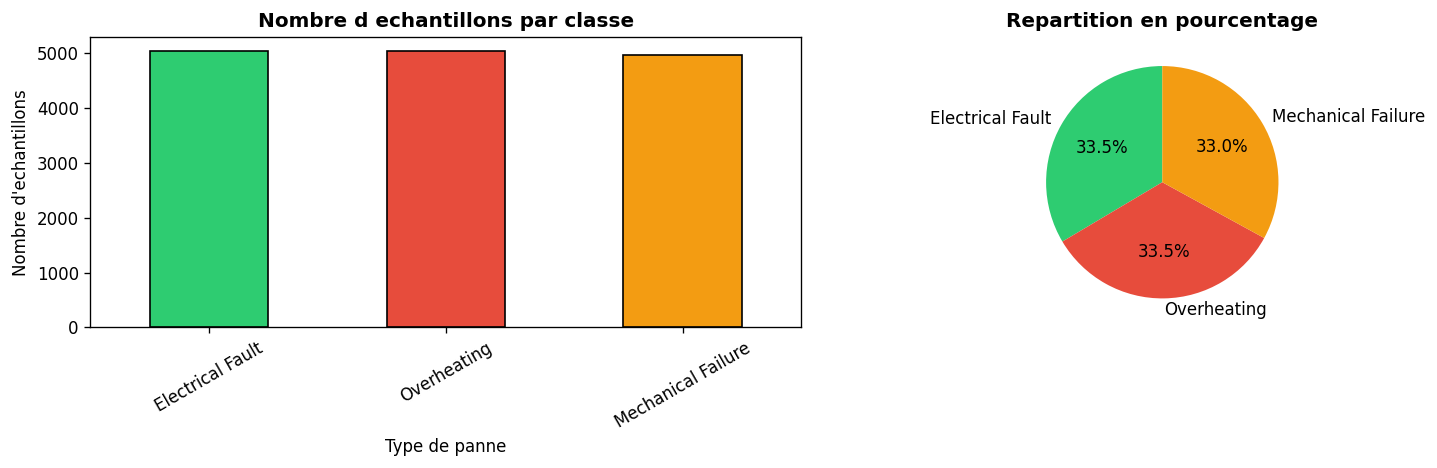

Figure sauvegardee : outputs/distribution_classes.png


In [20]:
label_counts = df[LABEL_COL].value_counts()
print("Distribution des classes :")
print(label_counts)
print(f"\nDesequilibre max/min : {label_counts.max() / label_counts.min():.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db']

label_counts.plot(kind='bar', ax=axes[0],
                  color=colors[:len(label_counts)], edgecolor='black')
axes[0].set_title('Nombre d echantillons par classe', fontweight='bold')
axes[0].set_xlabel('Type de panne')
axes[0].set_ylabel("Nombre d'echantillons")
axes[0].tick_params(axis='x', rotation=30)

axes[1].pie(label_counts, labels=label_counts.index,
            autopct='%1.1f%%', colors=colors[:len(label_counts)], startangle=90)
axes[1].set_title('Repartition en pourcentage', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distribution_classes.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/distribution_classes.png")

---
## 6. Detection des Colonnes Capteurs

In [21]:
cols = df.columns.tolist()

current_cols = [c for c in cols if re.search(r'current|^i(_|[0-9])|^i[0-9]', c, re.I)]
voltage_cols = [c for c in cols if re.search(r'voltage|volt|v(_|[0-9])|^v[0-9]', c, re.I)]
rpm_cols     = [c for c in cols if re.search(r'rpm|speed|vel|velocity', c, re.I)]

use_raw_windows = len(current_cols) > 5 or len(voltage_cols) > 5

print("Colonnes capteurs detectees :")
print(f"  Courant ({len(current_cols)}) : {current_cols[:8]}")
print(f"  Tension ({len(voltage_cols)}) : {voltage_cols[:8]}")
print(f"  Vitesse ({len(rpm_cols)})     : {rpm_cols[:8]}")
print()
print(f"Mode : {'Fenetres temporelles brutes' if use_raw_windows else 'Colonnes numeriques directes'}")

Colonnes capteurs detectees :
  Courant (2) : ['Current', 'Normalized_Current']
  Tension (2) : ['Voltage', 'Normalized_Voltage']
  Vitesse (0)     : []

Mode : Colonnes numeriques directes


---
## 7. Extraction de Features

17 features extraites depuis les 3 capteurs :

| Capteur | Features |
|---------|----------|
| Courant | peak, mean, rms, std, energy, area, di/dt_peak, di/dt_mean, duration, skewness, kurtosis |
| Tension | min, mean, drop |
| Vitesse | rpm_avant, rpm_apres, rpm_chute |

In [22]:
def extract_features_from_row(i_vals, v_vals=None, rpm_vals=None, fs=1000):
    """
    Extrait des features statistiques et temporelles depuis les signaux capteurs.

    Parametres
    ----------
    i_vals   : array-like  -- valeurs de courant (fenetre)
    v_vals   : array-like  -- valeurs de tension  (optionnel)
    rpm_vals : array-like  -- valeurs RPM          (optionnel)
    fs       : int         -- frequence echantillonnage (Hz)

    Retourne
    --------
    list de 17 features numeriques
    """
    dt = 1.0 / fs
    I  = np.array(i_vals).astype(float) if i_vals is not None else np.array([])

    # --- Features courant ---
    if I.size == 0:
        peak = mean = rms = std = energy = area = 0.0
        di_dt_peak = di_dt_mean = duration = skew = kurt = 0.0
    else:
        peak       = np.max(I)
        mean       = np.mean(I)
        rms        = np.sqrt(np.mean(I ** 2))
        std        = np.std(I)
        energy     = np.sum(I ** 2) * dt
        area       = np.trapz(I, dx=dt) if I.size > 1 else 0.0
        di         = np.diff(I) / dt if I.size > 1 else np.array([0.0])
        di_dt_peak = np.max(np.abs(di)) if di.size > 0 else 0.0
        di_dt_mean = np.mean(di)        if di.size > 0 else 0.0
        thr        = 0.5 * peak if peak != 0 else 0.0
        duration   = np.sum(I > thr) * dt
        skew       = stats.skew(I)
        kurt       = stats.kurtosis(I)

    feats = [peak, mean, rms, std, energy, area,
             di_dt_peak, di_dt_mean, duration, skew, kurt]

    # --- Features tension ---
    if v_vals is not None and len(v_vals) > 0:
        V      = np.array(v_vals).astype(float)
        feats += [np.min(V), np.mean(V), np.max(V) - np.min(V)]
    else:
        feats += [0.0, 0.0, 0.0]

    # --- Features vitesse ---
    if rpm_vals is not None and len(rpm_vals) > 0:
        R       = np.array(rpm_vals).astype(float)
        mid     = len(R) // 2
        rpm_bef = np.mean(R[:mid]) if len(R) > 1 else R.mean()
        rpm_aft = np.mean(R[mid:]) if len(R) > 1 else R.mean()
        feats  += [rpm_bef, rpm_aft, rpm_bef - rpm_aft]
    else:
        feats += [0.0, 0.0, 0.0]

    return feats  # 17 valeurs


FEATURE_NAMES = [
    'I_peak', 'I_mean', 'I_rms', 'I_std', 'I_energy', 'I_area',
    'I_didt_peak', 'I_didt_mean', 'I_duration', 'I_skewness', 'I_kurtosis',
    'V_min', 'V_mean', 'V_drop',
    'RPM_before', 'RPM_after', 'RPM_drop'
]

print(f"Fonction d extraction definie — {len(FEATURE_NAMES)} features par echantillon.")

Fonction d extraction definie — 17 features par echantillon.


---
## 8. Construction de la Matrice de Features (X, y)

In [23]:
if use_raw_windows:
    print("Mode : extraction depuis fenetres temporelles")
    current_cols_s = sorted(current_cols)
    voltage_cols_s = sorted(voltage_cols)
    rpm_cols_s     = sorted(rpm_cols)

    features_list, labels = [], []
    for _, row in df.iterrows():
        i_vals = row[current_cols_s].values if current_cols_s else None
        v_vals = row[voltage_cols_s].values if voltage_cols_s else None
        r_vals = row[rpm_cols_s].values     if rpm_cols_s     else None
        features_list.append(
            extract_features_from_row(i_vals, v_vals, r_vals, fs=SAMPLE_FREQ)
        )
        labels.append(row[LABEL_COL])

    X = np.vstack(features_list)
    y = np.array(labels)

else:
    print("Mode : colonnes numeriques directes")
    exclude_cols = [LABEL_COL, 'timestamp', 'time', 'id', 'index']
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

    if len(numeric_cols) == 0:
        raise ValueError("Aucune colonne numerique trouvee pour les features.")

    X = df[numeric_cols].values
    y = df[LABEL_COL].values

# Remplacer NaN/Inf par 0 (peut survenir lors de l'extraction de features)
X = np.nan_to_num(X.astype(float), nan=0.0, posinf=0.0, neginf=0.0)

print(f"Matrice X : {X.shape}")
print(f"Vecteur y : {len(y)} labels")


Mode : colonnes numeriques directes
Matrice X : (50000, 14)
Vecteur y : 50000 labels


In [24]:
# feat_names_used : liste de noms de colonnes utilisee dans toutes les cellules suivantes
feat_names_used = FEATURE_NAMES if use_raw_windows else numeric_cols

df_feat = pd.DataFrame(X, columns=feat_names_used[:X.shape[1]])
df_feat[LABEL_COL] = y
print("Apercu des features :")
df_feat.head()


Apercu des features :


,Temperature,Vibration,Pressure,Voltage,Current,FFT_Feature1,FFT_Feature2,Normalized_Temp,Normalized_Vibration,Normalized_Pressure,Normalized_Voltage,Normalized_Current,Anomaly_Score,Fault_Status,Fault_Type
0,47.698252,34.225292,176.199516,241.587771,8.323269,0.224737,0.093476,0.524226,0.211423,0.397119,0.800961,0.446526,0.239856,0.0,NaN
1,67.260549,134.072771,110.942636,235.003165,11.072823,0.973402,0.628513,0.682771,0.672347,0.240942,0.720230,0.552688,0.776081,0.0,NaN
2,45.056722,70.595452,246.739554,232.244324,10.353556,0.566625,0.417355,0.502817,0.379318,0.565941,0.686405,0.524917,0.039005,0.0,NaN
3,40.260670,98.252385,202.632051,225.922517,10.228006,0.872516,0.926135,0.463947,0.506990,0.460380,0.608896,0.520069,0.584953,0.0,NaN
4,56.311983,138.959633,231.149735,198.928891,18.878552,0.876380,0.174530,0.594037,0.694906,0.528630,0.277939,0.854070,0.944961,0.0,NaN


---
## 9. Encodage des Labels et Separation Train / Test

In [25]:
le    = LabelEncoder()
y_enc = le.fit_transform(y)

# Convertir les classes en strings (evite TypeError si labels numeriques)
CLASS_NAMES = [str(c) for c in le.classes_]

print("Classes encodees :")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}  ->  {cls}  ({np.sum(y_enc == i)} echantillons)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

print(f"\nTrain : {X_train.shape[0]} echantillons")
print(f"Test  : {X_test.shape[0]} echantillons")

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("\nNormalisation appliquee (moyenne=0, ecart-type=1).")


Classes encodees :
  0  ->  Electrical Fault  (5034 echantillons)
  1  ->  Mechanical Failure  (4950 echantillons)
  2  ->  Overheating  (5028 echantillons)
  3  ->  nan  (34988 echantillons)

Train : 40000 echantillons
Test  : 10000 echantillons

Normalisation appliquee (moyenne=0, ecart-type=1).


---
## 10. Modele 1 — Random Forest Classifier

In [26]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)

print(f"Random Forest — Accuracy : {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")
print()
print(classification_report(
    y_test, y_pred_rf,
    target_names=CLASS_NAMES,   # strings garantis
    zero_division=0             # evite UndefinedMetricWarning
))


Random Forest — Accuracy : 80.13%

                    precision    recall  f1-score   support

  Electrical Fault       0.33      0.34      0.34      1007
Mechanical Failure       0.33      0.33      0.33       990
       Overheating       0.35      0.34      0.35      1006
               nan       1.00      1.00      1.00      6997

          accuracy                           0.80     10000
         macro avg       0.50      0.50      0.50     10000
      weighted avg       0.80      0.80      0.80     10000



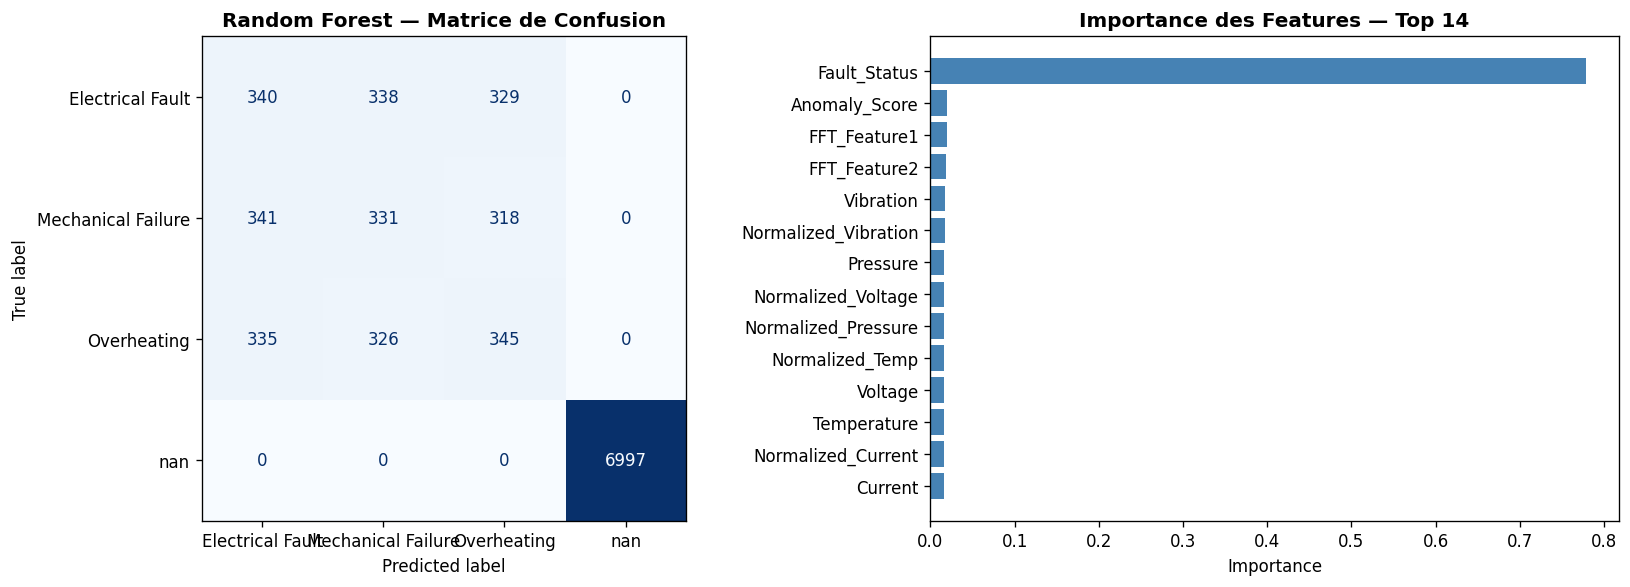

Figure sauvegardee : outputs/rf_results.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap='Blues', colorbar=False
)
axes[0].set_title('Random Forest — Matrice de Confusion', fontweight='bold')

importances = rf.feature_importances_
feat_plot   = list(feat_names_used)[:len(importances)]
top_n       = min(15, len(feat_plot))
sorted_idx  = np.argsort(importances)[::-1][:top_n]
axes[1].barh(
    [feat_plot[i] for i in sorted_idx[::-1]],
    importances[sorted_idx[::-1]],
    color='steelblue'
)
axes[1].set_title(f'Importance des Features — Top {top_n}', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rf_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/rf_results.png")


---
## 11. Modele 2 — MLP (Reseau de Neurones sklearn)

Architecture : `Input` -> **64 neurones** -> **32 neurones** -> `Output (3 classes)`

In [28]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=400,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    verbose=False
)
mlp.fit(X_train_s, y_train)
y_pred_mlp = mlp.predict(X_test_s)

print(f"MLP — Accuracy   : {accuracy_score(y_test, y_pred_mlp) * 100:.2f}%")
print(f"MLP — Iterations : {mlp.n_iter_}")
print()
print(classification_report(
    y_test, y_pred_mlp,
    target_names=CLASS_NAMES,
    zero_division=0
))


MLP — Accuracy   : 80.07%
MLP — Iterations : 26

                    precision    recall  f1-score   support

  Electrical Fault       0.33      0.62      0.43      1007
Mechanical Failure       0.33      0.29      0.30       990
       Overheating       0.42      0.10      0.16      1006
               nan       1.00      1.00      1.00      6997

          accuracy                           0.80     10000
         macro avg       0.52      0.50      0.47     10000
      weighted avg       0.81      0.80      0.79     10000



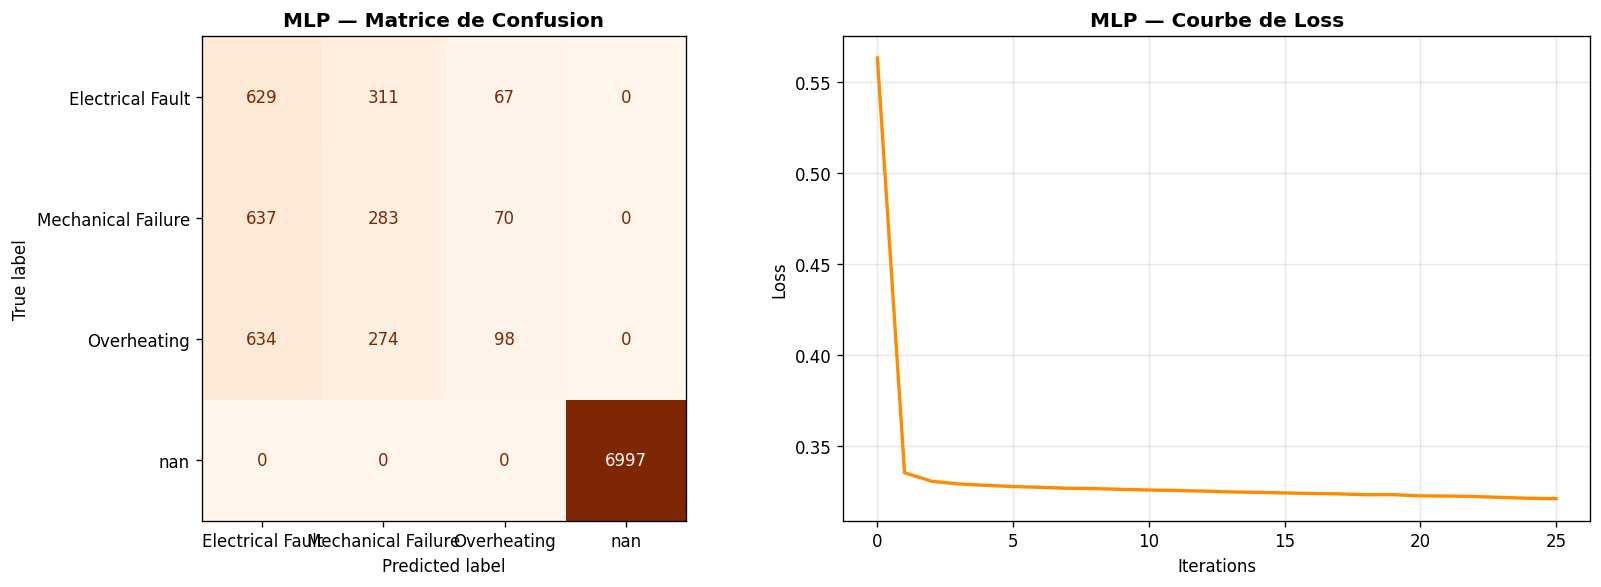

Figure sauvegardee : outputs/mlp_results.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
ConfusionMatrixDisplay(cm_mlp, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap='Oranges', colorbar=False
)
axes[0].set_title('MLP — Matrice de Confusion', fontweight='bold')

# Courbe de loss (loss_curve_ existe seulement si early_stopping=False ou apres fit)
if hasattr(mlp, 'loss_curve_') and mlp.loss_curve_:
    axes[1].plot(mlp.loss_curve_, color='darkorange', linewidth=2)
    axes[1].set_title('MLP — Courbe de Loss', fontweight='bold')
    axes[1].set_xlabel('Iterations')
    axes[1].set_ylabel('Loss')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'loss_curve_ non disponible',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('MLP — Courbe de Loss', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mlp_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/mlp_results.png")


---
## 12. Comparaison des Modeles

Comparaison des performances :
               Accuracy  Precision  Recall  F1-Score
Modele                                              
Random Forest     80.13      80.13   80.13     80.13
MLP (sklearn)     80.07      80.73   80.07     78.93


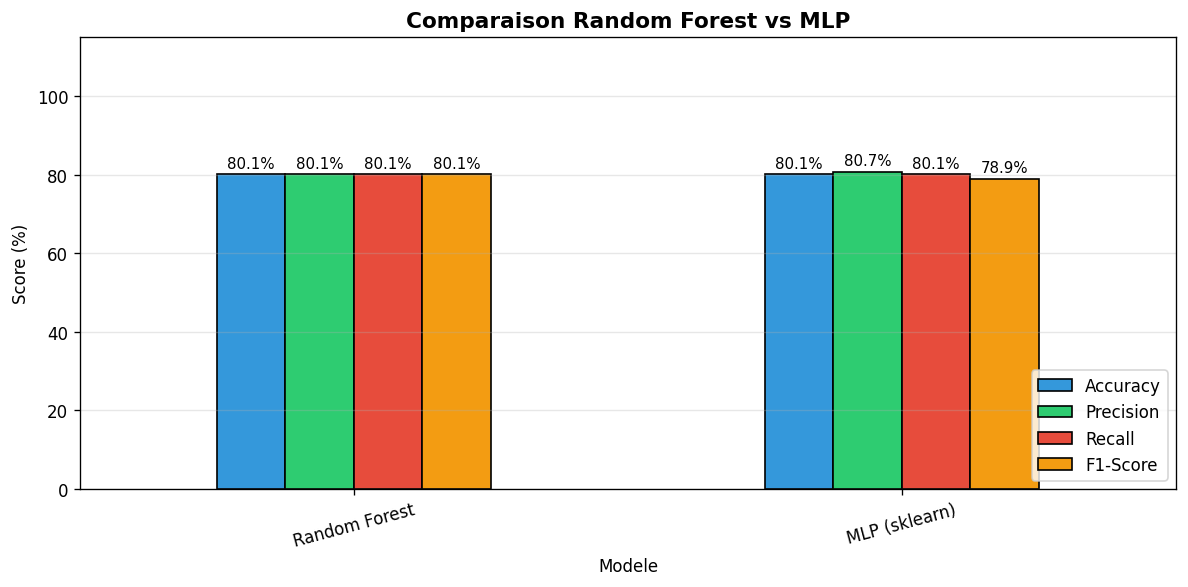

Figure sauvegardee : outputs/comparison.png


In [30]:
def get_metrics(y_true, y_pred, model_name):
    return {
        'Modele'    : model_name,
        'Accuracy'  : round(accuracy_score(y_true, y_pred) * 100, 2),
        'Precision' : round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'Recall'    : round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
        'F1-Score'  : round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2),
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_rf,  'Random Forest'),
    get_metrics(y_test, y_pred_mlp, 'MLP (sklearn)'),
]).set_index('Modele')

print("Comparaison des performances :")
print(results.to_string())

ax = results.plot(
    kind='bar', figsize=(10, 5),
    color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'],
    edgecolor='black', ylim=(0, 115)
)
ax.set_title('Comparaison Random Forest vs MLP', fontsize=13, fontweight='bold')
ax.set_ylabel('Score (%)')
ax.set_xticklabels(results.index, rotation=15)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure sauvegardee : {OUTPUT_DIR}/comparison.png")


---
## 13. Sauvegarde des Modeles

In [31]:
joblib.dump(rf,     os.path.join(OUTPUT_DIR, 'rf_model.joblib'))
joblib.dump(mlp,    os.path.join(OUTPUT_DIR, 'mlp_sklearn_model.joblib'))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.joblib'))
joblib.dump(le,     os.path.join(OUTPUT_DIR, 'label_encoder.joblib'))

print(f"Modeles sauvegardes dans '{OUTPUT_DIR}/' :")
for f in os.listdir(OUTPUT_DIR):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f"  {f}  ({size / 1024:.1f} KB)")

Modeles sauvegardes dans 'outputs/' :
  comparison.png  (45.2 KB)
  distribution_classes.png  (69.8 KB)
  label_encoder.joblib  (0.5 KB)
  mlp_results.png  (64.0 KB)
  mlp_sklearn_model.joblib  (82.8 KB)
  rf_model.joblib  (14424.0 KB)
  rf_results.png  (87.2 KB)
  scaler.joblib  (0.9 KB)


---
## 14. Test du Modele — Prediction sur Nouvelles Valeurs

> Entrez directement les valeurs de vos 3 capteurs pour tester le modele.

In [32]:
def predict_fault(current_A, voltage_V, rpm_val, model=None):
    """
    Predit le type de panne a partir de valeurs scalaires de capteurs.

    Parametres
    ----------
    current_A : float -- courant mesure (Amperes)
    voltage_V : float -- tension mesuree (Volts)
    rpm_val   : float -- vitesse mesuree (tours/min)
    model     : modele sklearn (rf par defaut)

    Retourne
    --------
    dict avec la classe predite et les probabilites par classe
    """
    if model is None:
        model = rf

    n_features = X_train_s.shape[1]

    if use_raw_windows:
        # Mode fenetres : construire un signal constant de 100 points
        i_window   = [current_A] * 100
        v_window   = [voltage_V] * 100
        rpm_window = [rpm_val]   * 100
        raw_feats  = extract_features_from_row(i_window, v_window, rpm_window, fs=SAMPLE_FREQ)
        sample     = np.array(raw_feats[:n_features] + [0.0] * max(0, n_features - len(raw_feats)))
    else:
        # Mode direct : remplir avec les moyennes du train, puis injecter les 3 capteurs
        # selon leur position dans numeric_cols
        mean_vals = X_train.mean(axis=0).copy()
        sample    = mean_vals.copy()
        for keyword, value in [
            (r'current|^i[_0-9]', current_A),
            (r'voltage|volt|^v[_0-9]', voltage_V),
            (r'rpm|speed|vel', rpm_val)
        ]:
            for j, col in enumerate(numeric_cols):
                if re.search(keyword, col, re.I):
                    sample[j] = value
                    break

    sample   = np.nan_to_num(sample.astype(float), nan=0.0)
    sample_s = scaler.transform(sample.reshape(1, -1))

    pred_idx   = model.predict(sample_s)[0]
    pred_proba = model.predict_proba(sample_s)[0]
    pred_label = le.inverse_transform([pred_idx])[0]

    result = {
        'Prediction'    : str(pred_label),
        'Confiance (%)' : round(float(np.max(pred_proba)) * 100, 2)
    }
    for cls, prob in zip(CLASS_NAMES, pred_proba):
        result[f'P({cls}) (%)'] = round(float(prob) * 100, 2)

    return result


print("Fonction predict_fault() prete.")


Fonction predict_fault() prete.


In [33]:
tests = [
    {"label": "Fonctionnement Normal", "current_A": 1.2,  "voltage_V": 11.8, "rpm_val": 3000},
    {"label": "Surcharge Simulee",     "current_A": 8.5,  "voltage_V": 10.5, "rpm_val": 1200},
    {"label": "Court-Circuit Simule",  "current_A": 25.0, "voltage_V": 2.0,  "rpm_val": 0},
]

print("=" * 60)
for test in tests:
    res = predict_fault(
        current_A=test["current_A"],
        voltage_V=test["voltage_V"],
        rpm_val=test["rpm_val"]
    )
    print(f"\nTest : {test['label']}")
    print(f"  I={test['current_A']} A | V={test['voltage_V']} V | RPM={test['rpm_val']}")
    for k, v in res.items():
        print(f"  {k} : {v}")
print("=" * 60)


Test : Fonctionnement Normal
  I=1.2 A | V=11.8 V | RPM=3000
  Prediction : nan
  Confiance (%) : 97.71
  P(Electrical Fault) (%) : 0.97
  P(Mechanical Failure) (%) : 0.52
  P(Overheating) (%) : 0.8
  P(nan) (%) : 97.71

Test : Surcharge Simulee
  I=8.5 A | V=10.5 V | RPM=1200
  Prediction : nan
  Confiance (%) : 97.71
  P(Electrical Fault) (%) : 0.97
  P(Mechanical Failure) (%) : 0.52
  P(Overheating) (%) : 0.8
  P(nan) (%) : 97.71

Test : Court-Circuit Simule
  I=25.0 A | V=2.0 V | RPM=0
  Prediction : nan
  Confiance (%) : 95.35
  P(Electrical Fault) (%) : 1.84
  P(Mechanical Failure) (%) : 0.96
  P(Overheating) (%) : 1.86
  P(nan) (%) : 95.35


---
## Recapitulatif du Pipeline

```
Dataset CSV
    |
    v
Detection colonnes capteurs (Courant / Tension / Vitesse)
    |
    v
Extraction de 17 features (statistiques temporelles)
    |
    v
Encodage LabelEncoder + Normalisation StandardScaler
    |
    +---> Random Forest  (200 arbres, max_depth=12, balanced)
    |
    +---> MLP sklearn    (64 -> 32, ReLU, Adam, early_stopping)
              |
              v
         Evaluation (Accuracy, F1, Precision, Recall)
              |
              v
         Sauvegarde .joblib dans outputs/
```

---
*Projet de Fin d'Annee II — Diagnostic de Moteurs DC 12V par IA*